In [2]:
#Section A1
import pandas as pd

df = pd.read_csv("diabetic_data.csv")

#binary target: 1 if readmitted within 30 days, otherwise 0
df["readmit_30d"] = (df["readmitted"] == "<30").astype(int)

df["readmit_30d"].value_counts()

#since discharge_date is not available, I used encounter_id as a time proxy

df = df.sort_values("encounter_id").reset_index(drop=True)

#each patient's latest encounter
patient_last_time = (
    df.groupby("patient_nbr")["encounter_id"]
    .max()
    .reset_index())

#ordering patients earlier to later
patient_last_time = patient_last_time.sort_values("encounter_id")

#Train/Validation/Test Split

n_patients = len(patient_last_time)

train_end = int(0.70 * n_patients)
val_end = int(0.85 * n_patients)

train_patients = patient_last_time.iloc[:train_end]["patient_nbr"]
val_patients = patient_last_time.iloc[train_end:val_end]["patient_nbr"]
test_patients = patient_last_time.iloc[val_end:]["patient_nbr"]

train_df = df[df["patient_nbr"].isin(train_patients)]
val_df = df[df["patient_nbr"].isin(val_patients)]
test_df = df[df["patient_nbr"].isin(test_patients)]

print("Train size:", len(train_df))
print("Validation size:", len(val_df))
print("Test size:", len(test_df))

#check overlaps
print("Train/Test overlap:", len(set(train_df["patient_nbr"]) & set(test_df["patient_nbr"])))
print("Train/Val overlap:", len(set(train_df["patient_nbr"]) & set(val_df["patient_nbr"])))
print("Val/Test overlap:", len(set(val_df["patient_nbr"]) & set(test_df["patient_nbr"])))

#readmission rates across splits
for name, data in [("Train", train_df), ("Validation", val_df), ("Test", test_df)]:
    rate = data["readmit_30d"].mean()
    print(name, "readmission rate:", round(rate, 3))

#summary table
summary = []

for name, data in [("Train", train_df), ("Validation", val_df), ("Test", test_df)]:
    summary.append({
        "Split": name,
        "Patients": data["patient_nbr"].nunique(),
        "Encounters": len(data),
        "Encounter ID Min": data["encounter_id"].min(),
        "Encounter ID Max": data["encounter_id"].max(),
        "Readmission Rate": round(data["readmit_30d"].mean(), 3)
})

summary_df = pd.DataFrame(summary)
summary_df

Train size: 66775
Validation size: 16547
Test size: 18444
Train/Test overlap: 0
Train/Val overlap: 0
Val/Test overlap: 0
Train readmission rate: 0.111
Validation readmission rate: 0.106
Test readmission rate: 0.119


,Split,Patients,Encounters,Encounter ID Min,Encounter ID Max,Readmission Rate
0,Train,50062,66775,12522,215537730,0.111
1,Validation,10728,16547,3595830,286696668,0.106
2,Test,10728,18444,11573388,443867222,0.119


In [3]:
#Section A2
from sklearn.dummy import DummyClassifier
from sklearn.metrics import average_precision_score, roc_auc_score

#split into features (X) and target (y)
drop_cols = ["readmitted", "readmit_30d", "encounter_id", "patient_nbr"]

X_train = train_df.drop(columns=drop_cols)
y_train = train_df["readmit_30d"]

X_val = val_df.drop(columns=drop_cols)
y_val = val_df["readmit_30d"]

X_test = test_df.drop(columns=drop_cols)
y_test = test_df["readmit_30d"]

#baseline model that just predicts based on class proportions
dummy = DummyClassifier(strategy="prior", random_state=42)
dummy.fit(X_train, y_train)

#predicted probabilities for readmission
val_probs = dummy.predict_proba(X_val)[:, 1]
test_probs = dummy.predict_proba(X_test)[:, 1]

#PR-AUC and ROC-AUC
val_pr_auc = average_precision_score(y_val, val_probs)
val_roc_auc = roc_auc_score(y_val, val_probs)

test_pr_auc = average_precision_score(y_test, test_probs)
test_roc_auc = roc_auc_score(y_test, test_probs)

#results table
results_a2 = pd.DataFrame({
    "Dataset": ["Validation", "Test"],
    "PR-AUC": [val_pr_auc, test_pr_auc],
    "ROC-AUC": [val_roc_auc, test_roc_auc]
})

results_a2["PR-AUC"] = results_a2["PR-AUC"].round(4)
results_a2["ROC-AUC"] = results_a2["ROC-AUC"].round(4)

print("Baseline results")
print(results_a2)

#class balance across splits
class_balance = pd.DataFrame({
    "Dataset": ["Train", "Validation", "Test"],
    "Readmission Rate": [
        y_train.mean(),
        y_val.mean(),
        y_test.mean()
    ]
})

class_balance["Readmission Rate"] = class_balance["Readmission Rate"].round(4)

print("\nClass balance")
print(class_balance)

Baseline results
      Dataset  PR-AUC  ROC-AUC
0  Validation  0.1058      0.5
1        Test  0.1189      0.5

Class balance
      Dataset  Readmission Rate
0       Train            0.1110
1  Validation            0.1058
2        Test            0.1189


In [4]:
#SectionB

import time
import numpy as np
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import average_precision_score, precision_recall_curve

#numeric vs categorical columns
numeric_cols = X_train.select_dtypes(include=["int64", "float64"]).columns
categorical_cols = X_train.select_dtypes(include=["object"]).columns

#preprocessing
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())])
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))])
preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_cols),
    ("cat", categorical_pipeline, categorical_cols)])

#function: recall when precision is at least 0.8
def recall_at_precision(y_true, y_prob, target_precision=0.8):
    precision, recall, thresholds = precision_recall_curve(y_true, y_prob)
    
    valid = precision >= target_precision
    if np.any(valid):
        return recall[valid].max()
    else:
        return 0.0

# three fixed learning rates
learning_rates = [1e-4, 1e-3, 1e-2]

results_B = []

for lr in learning_rates:
    
    model = Pipeline([
        ("preprocess", preprocessor),
        ("clf", SGDClassifier(
            loss="log_loss",
            learning_rate="constant",
            eta0=lr,
            alpha=0.0001,
            penalty="l2",
            class_weight="balanced",
            max_iter=1000,
            tol=1e-3,
            random_state=42
        ))])
    
    start = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - start

    #probabilities for each split
    train_prob = model.predict_proba(X_train)[:, 1]
    val_prob = model.predict_proba(X_val)[:, 1]
    test_prob = model.predict_proba(X_test)[:, 1]

    #PR-AUC
    train_pr = average_precision_score(y_train, train_prob)
    val_pr = average_precision_score(y_val, val_prob)
    test_pr = average_precision_score(y_test, test_prob)

    #val recall at precision >= 0.8
    val_recall_p80 = recall_at_precision(y_val, val_prob, 0.8)

    results_B.append({
        "LR (eta0)": lr,
        "Train PR-AUC": train_pr,
        "Val PR-AUC": val_pr,
        "Test PR-AUC": test_pr,
        "Val Rec@P>=0.8": val_recall_p80,
        "Train time (s)": train_time})

results_B = pd.DataFrame(results_B).round(4)

print(results_B)

   LR (eta0)  Train PR-AUC  Val PR-AUC  Test PR-AUC  Val Rec@P>=0.8  \
0     0.0001        0.1968      0.1995       0.2143          0.0000   
1     0.0010        0.2054      0.1978       0.2123          0.0000   
2     0.0100        0.1789      0.1551       0.1657          0.0006   

   Train time (s)  
0          1.5998  
1          1.6188  
2          2.1128  


In [6]:
#Section C
import time
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import SGDClassifier
from sklearn.model_selection import GridSearchCV, PredefinedSplit
from sklearn.metrics import average_precision_score


numeric_cols = X_train.select_dtypes(include=["int64", "float64"]).columns
categorical_cols = X_train.select_dtypes(include=["object"]).columns

#Preprocessing
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_cols),
    ("cat", categorical_pipeline, categorical_cols)])

#Base pipeline
pipe = Pipeline([
    ("preprocess", preprocessor),
    ("clf", SGDClassifier(
        loss="log_loss",
        learning_rate="constant",
        max_iter=1000,
        tol=1e-3,
        random_state=42
    ))])

#train + validation
X_train_val = pd.concat([X_train, X_val], axis=0)
y_train_val = pd.concat([y_train, y_val], axis=0)

#-1 = training fold, 0 = validation fold
test_fold = np.array([-1] * len(X_train) + [0] * len(X_val))
ps = PredefinedSplit(test_fold=test_fold)

param_grid = {
    "clf__eta0": [1e-4, 3e-4, 1e-3, 3e-3, 1e-2],
    "clf__alpha": [1e-6, 1e-5, 1e-4, 1e-3],
    "clf__penalty": ["l2", "l1"],
    "clf__class_weight": [None, "balanced"]
}

# Grid size check
n_candidates = (
    len(param_grid["clf__eta0"])
    * len(param_grid["clf__alpha"])
    * len(param_grid["clf__penalty"])
    * len(param_grid["clf__class_weight"]))

print("Total hyperparameter combinations:", n_candidates)

#Grid search
start_time = time.time()

grid = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    scoring="average_precision",   # PR-AUC
    cv=ps,
    n_jobs=-1,
    refit=True,
    return_train_score=False)

grid.fit(X_train_val, y_train_val)

total_runtime = time.time() - start_time

#results
cv_results = pd.DataFrame(grid.cv_results_)

results_C = cv_results[[
    "param_clf__eta0",
    "param_clf__alpha",
    "param_clf__penalty",
    "param_clf__class_weight",
    "mean_test_score",
    "rank_test_score"
]].copy()

results_C = results_C.rename(columns={
    "param_clf__eta0": "eta0",
    "param_clf__alpha": "alpha",
    "param_clf__penalty": "penalty",
    "param_clf__class_weight": "class_wt",
    "mean_test_score": "Mean Val PR-AUC",
    "rank_test_score": "Rank"})

results_C = results_C.sort_values(["Rank", "Mean Val PR-AUC"], ascending=[True, False])
results_C["Mean Val PR-AUC"] = results_C["Mean Val PR-AUC"].round(4)

#per-candidate runtime
avg_runtime_per_model = total_runtime / n_candidates
results_C["Runtime (s)"] = round(avg_runtime_per_model, 4)

top5_C = results_C.head(5).copy()

print("\nTop 5 grid search results:")
print(top5_C)

#Best model and final test score
best_model = grid.best_estimator_
best_params = grid.best_params_
best_val_pr_auc = grid.best_score_

test_probs = best_model.predict_proba(X_test)[:, 1]
test_pr_auc = average_precision_score(y_test, test_probs)

print("\nBest parameters:")
print(best_params)

print("\nBest validation PR-AUC:", round(best_val_pr_auc, 4))
print("Final test PR-AUC:", round(test_pr_auc, 4))

print("\nTotal number of model evaluations:", n_candidates * ps.get_n_splits())
print("Total runtime (s):", round(total_runtime, 4))

Total hyperparameter combinations: 80

Top 5 grid search results:
     eta0     alpha penalty class_wt  Mean Val PR-AUC  Rank  Runtime (s)
27  0.003  0.000010      l1     None           0.2062     1       0.7189
7   0.003  0.000001      l1     None           0.2050     2       0.7189
6   0.003  0.000001      l2     None           0.2049     3       0.7189
26  0.003  0.000010      l2     None           0.2049     4       0.7189
46  0.003  0.000100      l2     None           0.2049     5       0.7189

Best parameters:
{'clf__alpha': 1e-05, 'clf__class_weight': None, 'clf__eta0': 0.003, 'clf__penalty': 'l1'}

Best validation PR-AUC: 0.2062
Final test PR-AUC: 0.2173

Total number of model evaluations: 80
Total runtime (s): 57.5098


In [7]:
#Section D block 1

# rebuilding preprocessing pipeline for the Bayesian optimisation

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

numeric_cols = X_train.select_dtypes(include=["int64", "float64"]).columns
categorical_cols = X_train.select_dtypes(include=["object"]).columns

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_cols),
    ("cat", categorical_pipeline, categorical_cols)])

In [8]:
#Section D block 2

import time
import optuna
import matplotlib.pyplot as plt
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import average_precision_score
trial_history = []

#objective function for Bayesian optimisation:

def objective(trial):
   
    eta0 = trial.suggest_float("eta0", 1e-5, 1e-2, log=True)
    alpha = trial.suggest_float("alpha", 1e-7, 1e-2, log=True)
    penalty = trial.suggest_categorical("penalty", ["l1", "l2"])
    learning_rate = trial.suggest_categorical(
        "learning_rate",
        ["constant", "optimal", "invscaling", "adaptive"]
    )

    model = Pipeline([
        ("preprocess", preprocessor),
        ("clf", SGDClassifier(
            loss="log_loss",
            eta0=eta0,
            alpha=alpha,
            penalty=penalty,
            learning_rate=learning_rate,
            max_iter=1000,
            tol=1e-3,
            random_state=42))])

#train on training data and evaluate on validation set

    start = time.time()
    model.fit(X_train, y_train)
    runtime = time.time() - start

    val_probs = model.predict_proba(X_val)[:, 1]
    val_pr_auc = average_precision_score(y_val, val_probs)
    
#trial results for later analysis
    trial_history.append({
        "trial": trial.number + 1,
        "eta0": eta0,
        "alpha": alpha,
        "penalty": penalty,
        "learning_rate": learning_rate,
        "val_pr_auc": val_pr_auc,
        "runtime_s": runtime})

    return val_pr_auc

In [9]:
#Section D  Block 3
#Bayesian optimisation process
trial_history = []
optuna.logging.set_verbosity(optuna.logging.WARNING)

sampler = optuna.samplers.TPESampler(seed=42)

study = optuna.create_study(
    direction="maximize",
    sampler=sampler
)

start_total = time.time()

#optimisation for 30 trials

study.optimize(objective, n_trials=30)

total_runtime_s = time.time() - start_total

print("Best parameters:")
print(study.best_params)

print("\nBest validation PR-AUC:")
print(round(study.best_value, 4))

print("\nTotal runtime (s):")
print(round(total_runtime_s, 4))

Best parameters:
{'eta0': 0.0024413628451599415, 'alpha': 0.0001371194722561852, 'penalty': 'l2', 'learning_rate': 'optimal'}

Best validation PR-AUC:
0.2058

Total runtime (s):
82.0763


In [10]:
#Section D  Block 4

bayes_results = pd.DataFrame(trial_history)
# Sort by best validation PR-AUC
bayes_results = bayes_results.sort_values(
    by="val_pr_auc", ascending=False
).reset_index(drop=True)

bayes_results["val_pr_auc"] = bayes_results["val_pr_auc"].round(4)
bayes_results["runtime_s"] = bayes_results["runtime_s"].round(4)

print("Top 5 Bayesian optimisation trials:")
print(bayes_results.head(5))

Top 5 Bayesian optimisation trials:
   trial      eta0         alpha penalty learning_rate  val_pr_auc  runtime_s
0     28  0.002441  1.371195e-04      l2       optimal      0.2058     1.9844
1     29  0.002473  1.161129e-04      l2       optimal      0.2050     2.0080
2     25  0.003301  2.355460e-06      l2      adaptive      0.2042     2.4487
3     26  0.002578  1.541076e-05      l2      adaptive      0.2042     2.6612
4     23  0.003646  3.141324e-07      l2      adaptive      0.2042     2.5956


In [11]:
#Section D  Block 5
best_params = study.best_params

best_model = Pipeline([
    ("preprocess", preprocessor),
    ("clf", SGDClassifier(
        loss="log_loss",
        eta0=best_params["eta0"],
        alpha=best_params["alpha"],
        penalty=best_params["penalty"],
        learning_rate=best_params["learning_rate"],
        max_iter=1000,
        tol=1e-3,
        random_state=42
    ))
])

best_model.fit(X_train, y_train)

test_probs = best_model.predict_proba(X_test)[:, 1]
test_pr_auc = average_precision_score(y_test, test_probs)

print("Best validation PR-AUC:", round(study.best_value, 4))
print("Final test PR-AUC:", round(test_pr_auc, 4))

Best validation PR-AUC: 0.2058
Final test PR-AUC: 0.2139


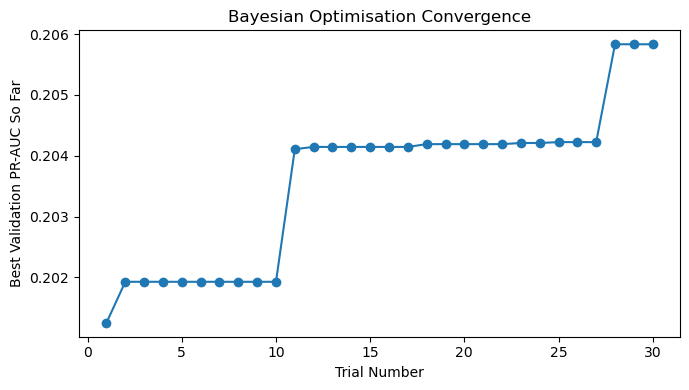

In [12]:
#Section D  Block 6
import pandas as pd
import numpy as np

best_so_far = np.maximum.accumulate([t["val_pr_auc"] for t in trial_history])

plt.figure(figsize=(7, 4))
plt.plot(range(1, len(best_so_far) + 1), best_so_far, marker="o")
plt.xlabel("Trial Number")
plt.ylabel("Best Validation PR-AUC So Far")
plt.title("Bayesian Optimisation Convergence")
plt.tight_layout()
plt.savefig("bayesian_convergence.png", dpi=300, bbox_inches="tight")
plt.show()

In [13]:
#Section D  Block 7
bayes_summary = pd.DataFrame({
    "Metric": [
        "Best Validation PR-AUC",
        "Final Test PR-AUC",
        "Number of Evaluations",
        "Total Runtime (s)",
        "Total Runtime (min)"
    ],
    "Value": [
        round(study.best_value, 4),
        round(test_pr_auc, 4),
        len(trial_history),
        round(total_runtime_s, 4),
        round(total_runtime_s / 60, 4)
    ]
})

print(bayes_summary)

                   Metric    Value
0  Best Validation PR-AUC   0.2058
1       Final Test PR-AUC   0.2139
2   Number of Evaluations  30.0000
3       Total Runtime (s)  82.0763
4     Total Runtime (min)   1.3679


In [14]:
#Section D  Block 8
grid_best_val = 0.2062
grid_test_pr = 0.2173
grid_evals = 80
grid_runtime_s = 117.0072

bayes_best_val = study.best_value
bayes_test_pr = test_pr_auc
bayes_evals = len(trial_history)
bayes_runtime_s = total_runtime_s

comparison_df = pd.DataFrame({
    "Method": ["Grid Search", "Bayesian Opt"],
    "#Evals": [grid_evals, bayes_evals],
    "Runtime (min)": [round(grid_runtime_s / 60, 4), round(bayes_runtime_s / 60, 4)],
    "Best Val PR-AUC": [round(grid_best_val, 4), round(bayes_best_val, 4)],
    "Test PR-AUC": [round(grid_test_pr, 4), round(bayes_test_pr, 4)],
    "Notes": [
        "Exhaustive search",
        "Sample-efficient search"
    ]
})

print(comparison_df)

         Method  #Evals  Runtime (min)  Best Val PR-AUC  Test PR-AUC  \
0   Grid Search      80         1.9501           0.2062       0.2173   
1  Bayesian Opt      30         1.3679           0.2058       0.2139   

                     Notes  
0        Exhaustive search  
1  Sample-efficient search  


In [15]:
#Section D  Block 9
top5_bayes = bayes_results.head(5).copy()
top5_bayes.index = np.arange(1, len(top5_bayes) + 1)
print(top5_bayes)

   trial      eta0         alpha penalty learning_rate  val_pr_auc  runtime_s
1     28  0.002441  1.371195e-04      l2       optimal      0.2058     1.9844
2     29  0.002473  1.161129e-04      l2       optimal      0.2050     2.0080
3     25  0.003301  2.355460e-06      l2      adaptive      0.2042     2.4487
4     26  0.002578  1.541076e-05      l2      adaptive      0.2042     2.6612
5     23  0.003646  3.141324e-07      l2      adaptive      0.2042     2.5956


In [18]:
#Q7 Bonus block 1

from sklearn.experimental import enable_halving_search_cv
import time
import numpy as np
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import SGDClassifier
from sklearn.model_selection import HalvingGridSearchCV, PredefinedSplit
from sklearn.metrics import average_precision_score

numeric_cols = X_train.select_dtypes(include=["int64", "float64"]).columns
categorical_cols = X_train.select_dtypes(include=["object"]).columns

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_cols),
    ("cat", categorical_pipeline, categorical_cols)])

X_train_val = pd.concat([X_train, X_val], axis=0)
y_train_val = pd.concat([y_train, y_val], axis=0)

test_fold = np.array([-1] * len(X_train) + [0] * len(X_val))
ps = PredefinedSplit(test_fold=test_fold)

In [20]:
#Q7 Bonus - Block 2
#same hyperparameter grid as Section C

param_grid = {
    "clf__eta0": [1e-4, 3e-4, 1e-3, 3e-3, 1e-2],
    "clf__alpha": [1e-6, 1e-5, 1e-4, 1e-3],
    "clf__penalty": ["l2", "l1"],
    "clf__class_weight": [None, "balanced"]
}

#total number of possible combinations
full_grid_size = (
    len(param_grid["clf__eta0"])
    * len(param_grid["clf__alpha"])
    * len(param_grid["clf__penalty"])
    * len(param_grid["clf__class_weight"])
)

print("Full Section C grid size:", full_grid_size)

Full Section C grid size: 80


In [22]:
#Q7 Bonus block 3

#base model pipeline (same structure as Section C)
pipe = Pipeline([
    ("preprocess", preprocessor),
    ("clf", SGDClassifier(
        loss="log_loss",
        learning_rate="constant",
        max_iter=1000,
        tol=1e-3,
        random_state=42
    ))
])

# start timing the halving search
start_time = time.time()

halving = HalvingGridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    scoring="average_precision",   # use PR-AUC
    cv=ps,
    factor=3,                      
    resource="clf__max_iter",      
    max_resources=1000,
    min_resources=100,
    n_jobs=-1,
    refit=True,
    return_train_score=False
)

halving.fit(X_train_val, y_train_val)

halving_runtime_s = time.time() - start_time

#best results
print("Best parameters:")
print(halving.best_params_)

print("\nBest validation PR-AUC:")
print(round(halving.best_score_, 4))

print("\nTotal runtime (s):")
print(round(halving_runtime_s, 4))

Best parameters:
{'clf__alpha': 1e-05, 'clf__class_weight': None, 'clf__eta0': 0.003, 'clf__penalty': 'l1', 'clf__max_iter': 900}

Best validation PR-AUC:
0.2062

Total runtime (s):
103.5232


In [23]:
#Q7 Bonus - Block 4

halving_results = pd.DataFrame(halving.cv_results_)

bonus_results = halving_results[[
    "params",
    "mean_test_score",
    "rank_test_score",
    "iter",
    "n_resources"
]].copy()

params_df = pd.json_normalize(bonus_results["params"])

bonus_results = pd.concat(
    [
        bonus_results.drop(columns=["params"]).reset_index(drop=True),
        params_df.reset_index(drop=True)
    ],
    axis=1
)

# renaming columns
bonus_results = bonus_results.rename(columns={
    "mean_test_score": "Mean Val PR-AUC",
    "rank_test_score": "Rank",
    "iter": "Iteration",
    "n_resources": "Resources",
    "clf__eta0": "eta0",
    "clf__alpha": "alpha",
    "clf__penalty": "penalty",
    "clf__class_weight": "class_wt",
    "clf__max_iter": "max_iter"
})

bonus_results["Mean Val PR-AUC"] = bonus_results["Mean Val PR-AUC"].round(4)

#strongest results first
bonus_results = bonus_results.sort_values(
    ["Rank", "Mean Val PR-AUC"], ascending=[True, False]
).reset_index(drop=True)

print("Top 5 HalvingGridSearchCV results:")
print(bonus_results.head(5))

Top 5 HalvingGridSearchCV results:
   Mean Val PR-AUC  Rank  Iteration  Resources     alpha class_wt   eta0  \
0           0.2062     1          0        100  0.000010     None  0.003   
1           0.2062     1          1        300  0.000010     None  0.003   
2           0.2062     1          2        900  0.000010     None  0.003   
3           0.2050     4          0        100  0.000001     None  0.003   
4           0.2050     4          1        300  0.000001     None  0.003   

  penalty  max_iter  
0      l1       100  
1      l1       300  
2      l1       900  
3      l1       100  
4      l1       300  


In [24]:
# Q7 Bonus block 5

#best halving model on the test set

halving_best_model = halving.best_estimator_

halving_test_probs = halving_best_model.predict_proba(X_test)[:, 1]
halving_test_pr_auc = average_precision_score(y_test, halving_test_probs)

print("Best validation PR-AUC:", round(halving.best_score_, 4))
print("Final test PR-AUC:", round(halving_test_pr_auc, 4))


#how many models were actually trained

halving_evals = len(halving.cv_results_)

print("Number of models trained by HalvingGridSearchCV:", halving_evals)


#halving search vs standard grid search

grid_best_val = 0.2062
grid_test_pr = 0.2173
grid_runtime_s = 57.5098
grid_evals = 80

halving_best_val = halving.best_score_
halving_test_pr = halving_test_pr_auc
halving_runtime_min = halving_runtime_s / 60
grid_runtime_min = grid_runtime_s / 60

comparison_bonus = pd.DataFrame({
    "Method": ["Grid Search", "Halving Grid Search"],
    "#Models Trained": [grid_evals, halving_evals],
    "Runtime (min)": [
        round(grid_runtime_min, 4),
        round(halving_runtime_min, 4)
    ],
    "Best Val PR-AUC": [
        round(grid_best_val, 4),
        round(halving_best_val, 4)
    ],
    "Test PR-AUC": [
        round(grid_test_pr, 4),
        round(halving_test_pr, 4)
    ],
    "Notes": [
        "Exhaustive",
        "Successive elimination"
    ]
})

print(comparison_bonus)

Best validation PR-AUC: 0.2062
Final test PR-AUC: 0.2173
Number of models trained by HalvingGridSearchCV: 16
                Method  #Models Trained  Runtime (min)  Best Val PR-AUC  \
0          Grid Search               80         0.9585           0.2062   
1  Halving Grid Search               16         1.7254           0.2062   

   Test PR-AUC                   Notes  
0       0.2173              Exhaustive  
1       0.2173  Successive elimination  


In [28]:
#FINAL CSV TO SUBMIT

import pandas as pd
import numpy as np

all_results = []

for i in range(len(results_B)):
    
    row = {
        "method": "learning_rate_sweep",
        "eta0": results_B.loc[i, "LR (eta0)"],
        "alpha": 1e-4,
        "penalty": "l2",
        "class_weight": "balanced",
        "val_pr_auc": results_B.loc[i, "Val PR-AUC"],
        "test_pr_auc": results_B.loc[i, "Test PR-AUC"],
        "runtime_s": results_B.loc[i, "Train time (s)"],
        "seed": 42,
        "fold": "train_val_split"
    }
    
    all_results.append(row)


#Grid Search

for i in range(len(cv_results)):

    row = {
        "method": "grid_search",
        "eta0": cv_results.loc[i, "param_clf__eta0"],
        "alpha": cv_results.loc[i, "param_clf__alpha"],
        "penalty": cv_results.loc[i, "param_clf__penalty"],
        "class_weight": cv_results.loc[i, "param_clf__class_weight"],
        "val_pr_auc": cv_results.loc[i, "mean_test_score"],
        "test_pr_auc": np.nan,
        "runtime_s": total_runtime / len(cv_results),
        "seed": 42,
        "fold": "predefined_split"
    }

    all_results.append(row)

#Bayesian

for i in range(len(bayes_results)):

    row = {
        "method": "bayesian_opt",
        "eta0": bayes_results.loc[i, "eta0"],
        "alpha": bayes_results.loc[i, "alpha"],
        "penalty": bayes_results.loc[i, "penalty"],
        "class_weight": np.nan,
        "val_pr_auc": bayes_results.loc[i, "val_pr_auc"],
        "test_pr_auc": np.nan,
        "runtime_s": bayes_results.loc[i, "runtime_s"],
        "seed": 42,
        "fold": "train_val_split"
    }

    all_results.append(row)

# BONUS — Halving

for i in range(len(bonus_results)):

    row = {
        "method": "halving_grid",
        "eta0": bonus_results.loc[i, "eta0"],
        "alpha": bonus_results.loc[i, "alpha"],
        "penalty": bonus_results.loc[i, "penalty"],
        "class_weight": bonus_results.loc[i, "class_wt"],
        "val_pr_auc": bonus_results.loc[i, "Mean Val PR-AUC"],
        "test_pr_auc": np.nan,
        "runtime_s": np.nan,
        "seed": 42,
        "fold": "predefined_split"
    }

    all_results.append(row)

final_results_df = pd.DataFrame(all_results)

print("Total rows:", len(final_results_df))

final_results_df.head()

Total rows: 229


,method,eta0,alpha,penalty,class_weight,val_pr_auc,test_pr_auc,runtime_s,seed,fold
0,learning_rate_sweep,0.0001,0.000100,l2,balanced,0.199500,0.2143,1.599800,42,train_val_split
1,learning_rate_sweep,0.0010,0.000100,l2,balanced,0.197800,0.2123,1.618800,42,train_val_split
2,learning_rate_sweep,0.0100,0.000100,l2,balanced,0.155100,0.1657,2.112800,42,train_val_split
3,grid_search,0.0001,0.000001,l2,None,0.199178,NaN,0.718873,42,predefined_split
4,grid_search,0.0001,0.000001,l1,None,0.199172,NaN,0.718873,42,predefined_split


In [29]:
final_results_df.to_csv(
    "assignment_results_all_runs.csv",
    index=False
)